U15 — Regression (finish): Lab

In [ ]:
# === SETUP: load the provided file (regenerate it if missing) ===
import os
import numpy as np
import pandas as pd


def build_turbine(csv_path="turbine_energy.csv", seed=152, verbose=False):
    """Wind-turbine daily energy yield — a nonlinear regression with a skewed target,
    correlated features, an outlier-prone signal and a feature that needs transforming.
    Ideal for residual diagnostics, transforms, regularisation and tree ensembles.

    Features:
      wind_speed_ms        average wind speed (m/s)
      wind_std_ms          gustiness (std of wind speed)
      air_density_kgm3     air density (kg/m^3)
      turbulence_intensity fraction (0-1)
      blade_pitch_deg      blade pitch angle (deg)
      rotor_rpm            rotor speed (rpm)
      ambient_temp_c       ambient temperature (deg C)
      turbine_age_years    age of the turbine (years)
    Target:
      energy_kwh           daily energy produced (kWh) — right-skewed
    """
    rng = np.random.default_rng(seed)
    N = 1600
    wind = np.clip(rng.weibull(2.0, N) * 7.0, 0.5, 26)          # Weibull -> right-skew
    wind_std = np.clip(0.12 * wind + rng.normal(0, 0.3, N), 0.05, None)
    density = np.clip(rng.normal(1.225, 0.04, N), 1.10, 1.35)
    turb = np.clip(rng.normal(0.14, 0.05, N), 0.02, 0.40)
    pitch = np.clip(rng.normal(4, 6, N), -2, 25)
    rpm = np.clip(8 + 0.9 * wind + rng.normal(0, 1.5, N), 4, 30)  # correlated with wind
    temp = rng.normal(15, 9, N).round(1)
    age = rng.uniform(0, 20, N)

    # power ~ density * v^3 up to rated, then flattens; losses from pitch, turbulence, age
    cube = np.minimum(wind, 13) ** 3                              # cubic then saturates near rated
    rated_extra = np.maximum(wind - 13, 0) * 120
    energy = (density * (3.1 * cube + rated_extra)
              - 35 * np.abs(pitch - 2)
              - 1800 * turb
              - 22 * age
              + rng.normal(0, 280, N))
    energy = np.clip(energy, 0, None)
    # a few sensor-glitch outliers
    g = rng.choice(N, 18, replace=False)
    energy[g] = energy[g] * rng.uniform(1.6, 2.4, len(g))

    df = pd.DataFrame({
        "wind_speed_ms": wind.round(2), "wind_std_ms": wind_std.round(2),
        "air_density_kgm3": density.round(3), "turbulence_intensity": turb.round(3),
        "blade_pitch_deg": pitch.round(1), "rotor_rpm": rpm.round(1),
        "ambient_temp_c": temp, "turbine_age_years": age.round(1),
        "energy_kwh": energy.round(1),
    })
    df.to_csv(csv_path, index=False)
    if verbose:
        from scipy.stats import skew
        print("turbine:", df.shape)
        print("energy range:", df.energy_kwh.min(), "-", df.energy_kwh.max())
        print("target skew:", round(skew(df.energy_kwh), 2))
        print("corr(wind, energy):", round(df.wind_speed_ms.corr(df.energy_kwh), 3))
        print("corr(wind, rpm):", round(df.wind_speed_ms.corr(df.rotor_rpm), 3))
    return df

if not os.path.exists('turbine_energy.csv'):
    build_turbine(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')


Generated dataset file.


In [ ]:

import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
df = pd.read_csv('turbine_energy.csv')
TARGET = 'energy_kwh'
features = [c for c in df.columns if c != TARGET]
X = df[features].values; y = df[TARGET].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print('shape:', df.shape, '| features:', len(features))
df.head(3)

shape: (1600, 9) | features: 8


,wind_speed_ms,wind_std_ms,air_density_kgm3,turbulence_intensity,blade_pitch_deg,rotor_rpm,ambient_temp_c,turbine_age_years,energy_kwh
0,4.95,0.81,1.238,0.185,-1.2,13.1,2.4,2.7,0.0
1,6.83,0.84,1.265,0.169,-2.0,15.3,12.1,5.9,527.2
2,1.44,0.05,1.225,0.114,-2.0,7.3,26.1,1.2,0.0


baseline RMSE: 1032.5 kWh | R2: 0.727


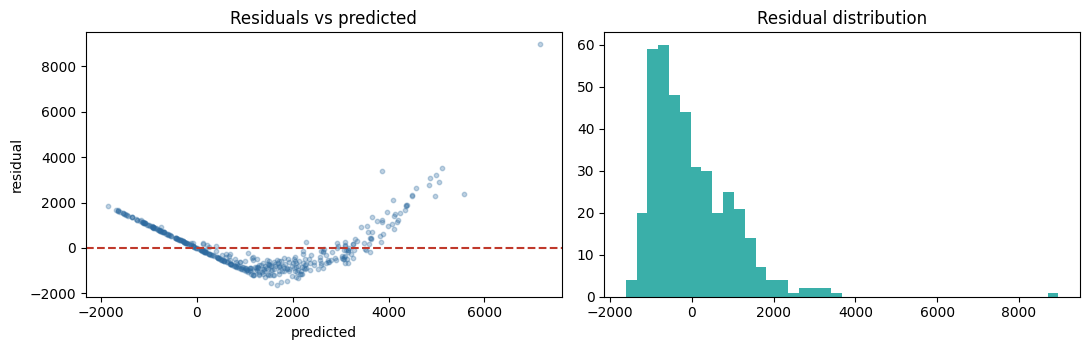

Look for curvature / a fan shape (heteroscedasticity) and skewed residuals.


In [ ]:

# -----------------------------------------------------------
# 🔹 1A. LINEAR BASELINE + RESIDUAL PLOT
# -----------------------------------------------------------
lin = LinearRegression().fit(X_train, y_train)
pred = lin.predict(X_test)
resid = y_test - pred
print(f'baseline RMSE: {mean_squared_error(y_test, pred) ** 0.5:.1f} kWh | R2: {r2_score(y_test, pred):.3f}')
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].scatter(pred, resid, s=10, alpha=0.3, color='#2D6A9F')
ax[0].axhline(0, color='#C0392B', ls='--'); ax[0].set_xlabel('predicted'); ax[0].set_ylabel('residual')
ax[0].set_title('Residuals vs predicted')
ax[1].hist(resid, bins=40, color='#3AAFA9'); ax[1].set_title('Residual distribution')
plt.tight_layout(); plt.show()
print('Look for curvature / a fan shape (heteroscedasticity) and skewed residuals.')

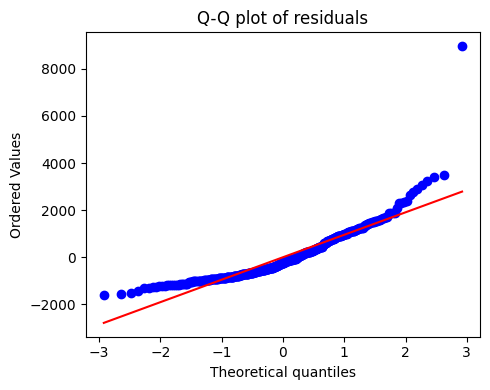

Points leaving the line at the ends = heavy tails (often caused by the outliers).


In [ ]:
# -----------------------------------------------------------
# 🔹 1B. Q-Q PLOT — ARE THE ERRORS NORMAL?
# -----------------------------------------------------------
from scipy import stats
fig, ax = plt.subplots(figsize=(5, 4))
stats.probplot(resid, dist='norm', plot=ax)
ax.set_title('Q-Q plot of residuals'); plt.tight_layout(); plt.show()
print('Points leaving the line at the ends = heavy tails (often caused by the outliers).')

In [ ]:
from scipy.stats import skew
# 1. describe the residual pattern: ...   (comment)


# 2. skew of the target
from scipy.stats import skew
target_skew = skew(y)

print("Target skew:", round(target_skew, 3))

if target_skew > 1:
    print("The target is right-skewed (skew > 1).")
else:
    print("The target is not strongly right-skewed (skew <= 1).")

Target skew: 2.211
The target is right-skewed (skew > 1).


In [ ]:
# -----------------------------------------------------------
# 🔹 2A. PHYSICS-INFORMED FEATURE TRANSFORM (power ~ wind^3)
# -----------------------------------------------------------
# The residual curve comes from the cubic wind->power law. Add wind^2 and wind^3.
wi = features.index('wind_speed_ms')
def add_wind_poly(M):
    w = M[:, wi:wi + 1]
    return np.hstack([M, w ** 2, w ** 3])
Xtr_aug, Xte_aug = add_wind_poly(X_train), add_wind_poly(X_test)
lin_aug = LinearRegression().fit(Xtr_aug, y_train)
pred_aug = lin_aug.predict(Xte_aug)
print(f'baseline           R2: {r2_score(y_test, pred):.3f}')
print(f'+ wind^2, wind^3   R2: {r2_score(y_test, pred_aug):.3f}')
print('Matching the feature to the physics straightens the relationship.')

baseline           R2: 0.727
+ wind^2, wind^3   R2: 0.935
Matching the feature to the physics straightens the relationship.


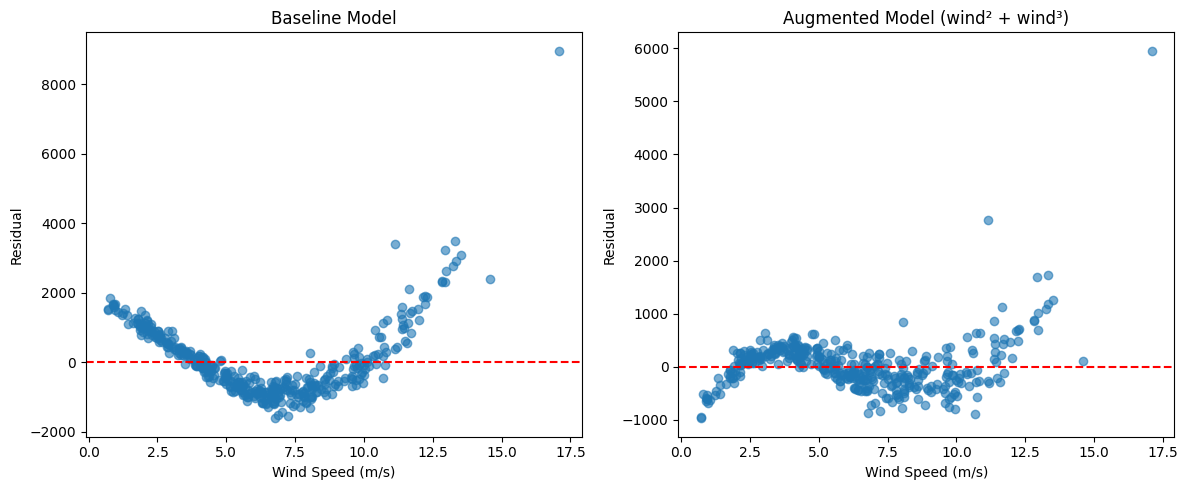

In [ ]:
import matplotlib.pyplot as plt

# Residuals for the baseline model
baseline_residuals = y_test - lin.predict(X_test)

# Residuals for the augmented model
augmented_residuals = y_test - lin_aug.predict(Xte_aug)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(X_test[:, wi], baseline_residuals, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Wind Speed (m/s)")
plt.ylabel("Residual")
plt.title("Baseline Model")
plt.subplot(1, 2, 2)
plt.scatter(X_test[:, wi], augmented_residuals, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Wind Speed (m/s)")
plt.ylabel("Residual")
plt.title("Augmented Model (wind² + wind³)")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
def score_model(model):
    m = make_pipeline(StandardScaler(), PolynomialFeatures(2, include_bias=False), model)
    m.fit(X_train, y_train)
    return r2_score(y_test, m.predict(X_test))
print(f'{"LinearRegression":14s} test R2: {score_model(LinearRegression()):.3f}')
for name, mdl in [('Ridge', Ridge(alpha=10.0)), ('Lasso', Lasso(alpha=1.0, max_iter=10000)),
                  ('ElasticNet', ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=10000))]:
    print(f'{name:14s} test R2: {score_model(mdl):.3f}')


LinearRegression test R2: 0.908
Ridge          test R2: 0.908
Lasso          test R2: 0.909
ElasticNet     test R2: 0.863


In [ ]:
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]

best_ratio = None
best_r2 = float("-inf")

for ratio in l1_ratios:
    model = ElasticNet(alpha=1.0, l1_ratio=ratio, random_state=42)
    r2 = score_model(model)   # Assumes score_model(model) returns the test R²
    print(f"l1_ratio = {ratio:.1f}, Test R² = {r2:.4f}")

    if r2 > best_r2:
        best_r2 = r2
        best_ratio = ratio

print(f"\nBest l1_ratio = {best_ratio}, Test R² = {best_r2:.4f}")

l1_ratio = 0.1, Test R² = 0.8331
l1_ratio = 0.3, Test R² = 0.8478
l1_ratio = 0.5, Test R² = 0.8628
l1_ratio = 0.7, Test R² = 0.8785
l1_ratio = 0.9, Test R² = 0.8976

Best l1_ratio = 0.9, Test R² = 0.8976


In [ ]:

# -----------------------------------------------------------
# 🔹 4A. ORDINARY vs ROBUST (Huber) REGRESSION
# -----------------------------------------------------------
from sklearn.linear_model import HuberRegressor
ols = make_pipeline(StandardScaler(), LinearRegression()).fit(X_train, y_train)
hub = make_pipeline(StandardScaler(), HuberRegressor(max_iter=2000)).fit(X_train, y_train)
print('OLS    test R2:', round(r2_score(y_test, ols.predict(X_test)), 3))
print('Huber  test R2:', round(r2_score(y_test, hub.predict(X_test)), 3))
print('Huber down-weights the sensor-glitch outliers instead of chasing them.')

OLS    test R2: 0.727
Huber  test R2: 0.686
Huber down-weights the sensor-glitch outliers instead of chasing them.


In [ ]:
import numpy as np
baseline_residuals = y_test - lin.predict(X_test)

# Standard deviation of residuals
sigma = np.std(baseline_residuals)

# Flag outliers (|residual| > 3σ)
outliers = np.abs(baseline_residuals) > 3 * sigma

# Count outliers
num_outliers = np.sum(outliers)

print("Number of outliers (|residual| > 3σ):", num_outliers)

Number of outliers (|residual| > 3σ): 4


In [ ]:

# -----------------------------------------------------------
# 🔹 5A. DECISION TREE vs RANDOM FOREST vs GRADIENT BOOSTING
# -----------------------------------------------------------
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
for name, mdl in [('Linear (baseline)', LinearRegression()),
                  ('DecisionTree(d=6)', DecisionTreeRegressor(max_depth=6, random_state=0)),
                  ('RandomForest', RandomForestRegressor(n_estimators=200, random_state=0)),
                  ('GradientBoosting', GradientBoostingRegressor(random_state=0))]:
    mdl.fit(X_train, y_train)
    print(f'{name:20s} test R2: {r2_score(y_test, mdl.predict(X_test)):.3f}')

Linear (baseline)    test R2: 0.727
DecisionTree(d=6)    test R2: 0.885
RandomForest         test R2: 0.933
GradientBoosting     test R2: 0.938


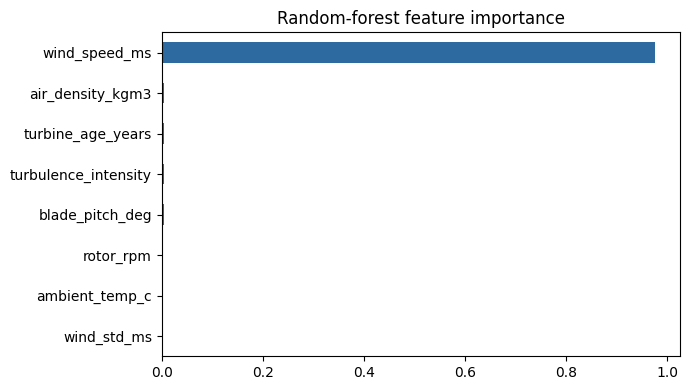

In [ ]:
rf = RandomForestRegressor(n_estimators=200, random_state=0).fit(X_train, y_train)
imp = pd.Series(rf.feature_importances_, index=features).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
imp.plot(kind='barh', color='#2D6A9F', ax=ax); ax.set_title('Random-forest feature importance')
plt.tight_layout(); plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score

# 1. Define the parameter grid
param_grid = {
    "max_depth": [6, 10, None],
    "n_estimators": [200, 400]
}
rf = RandomForestRegressor(random_state=42)

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

# Best model
best_rf = grid.best_estimator_

# Test R²
y_pred = best_rf.predict(X_test)
test_r2 = r2_score(y_test, y_pred)

print("Best Parameters:", grid.best_params_)
print("Best CV R²:", round(grid.best_score_, 4))
print("Test R²:", round(test_r2, 4))



Best Parameters: {'max_depth': 10, 'n_estimators': 200}
Best CV R²: 0.9654
Test R²: 0.933


U16_Classification_Part1_Lab

In [ ]:
# === SETUP: load the provided file (regenerate it if missing) ===
import os
import numpy as np
import pandas as pd


def build_welds(csv_path="weld_inspection.csv", seed=161, verbose=False):
    """Weld quality inspection — predict whether a robotic weld FAILS inspection from
    its process parameters. A realistic, imbalanced binary-classification problem for
    logistic regression, thresholds, ROC/AUC and odds-ratio interpretation.

    Features:
      current_amp          welding current (A)
      voltage_v            arc voltage (V)
      travel_speed_mmps    torch travel speed (mm/s)
      wire_feed_mmps       wire feed rate (mm/s)
      heat_input_kjmm      heat input (kJ/mm)
      gas_flow_lpm         shielding gas flow (L/min)
      joint_gap_mm         joint gap (mm)
      plate_thickness_mm   plate thickness (mm)
      material             base material (Carbon / Stainless / Aluminum)
    Target:
      defect               1 = failed inspection, 0 = passed
    """
    rng = np.random.default_rng(seed)
    N = 2600
    current = rng.normal(190, 30, N).clip(90, 300)
    voltage = (18 + 0.03 * current + rng.normal(0, 1.2, N)).clip(14, 32)
    travel = rng.normal(8, 2.2, N).clip(3, 16)
    wire = (current * 0.03 + rng.normal(0, 0.6, N)).clip(2, 12)
    heat = (voltage * current / (travel * 1000)).clip(0.2, 4.0)     # kJ/mm
    gas = rng.normal(16, 3, N).clip(6, 28)
    gap = rng.gamma(2.0, 0.35, N).clip(0, 4).round(2)               # right-skewed
    thick = rng.choice([3, 5, 6, 8, 10, 12, 16], N).astype(float)
    material = rng.choice(["Carbon", "Stainless", "Aluminum"], N, p=[0.55, 0.30, 0.15])
    mat_risk = np.select([material == "Carbon", material == "Stainless", material == "Aluminum"],
                         [0.0, 0.3, 0.8])                            # Aluminum harder to weld

    # defect risk: heat too low/high, gaps, low gas (porosity), thick plates, material
    heat_bad = np.abs(heat - 1.3)
    z = (-3.2
         + 1.6 * heat_bad
         + 1.1 * gap
         + 0.05 * (16 - gas)
         + 0.04 * (thick - 8)
         + 0.012 * (travel - 8) ** 2
         + mat_risk)
    p = 1 / (1 + np.exp(-z))
    defect = (rng.random(N) < p).astype(int)

    df = pd.DataFrame({
        "current_amp": current.round(1), "voltage_v": voltage.round(2),
        "travel_speed_mmps": travel.round(2), "wire_feed_mmps": wire.round(2),
        "heat_input_kjmm": heat.round(3), "gas_flow_lpm": gas.round(1),
        "joint_gap_mm": gap, "plate_thickness_mm": thick,
        "material": material, "defect": defect,
    })
    df.to_csv(csv_path, index=False)
    if verbose:
        print("welds:", df.shape)
        print("defect rate:", round(df.defect.mean(), 3))
        print("defect by material:\n",
              df.groupby("material")["defect"].mean().round(3).to_string())
    return df

if not os.path.exists('weld_inspection.csv'):
    build_welds(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')

Found the provided dataset file.


In [ ]:

import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
df = pd.read_csv('weld_inspection.csv')
print('shape:', df.shape, '| defect rate:', round(df.defect.mean(), 3))
df.head(3)

shape: (2600, 10) | defect rate: 0.281


,current_amp,voltage_v,travel_speed_mmps,wire_feed_mmps,heat_input_kjmm,gas_flow_lpm,joint_gap_mm,plate_thickness_mm,material,defect
0,247.7,23.37,7.78,7.57,0.744,16.0,0.79,8.0,Carbon,0
1,227.3,22.98,8.90,5.96,0.587,16.5,0.66,12.0,Carbon,0
2,230.6,24.46,8.15,7.76,0.692,12.0,0.81,10.0,Stainless,0


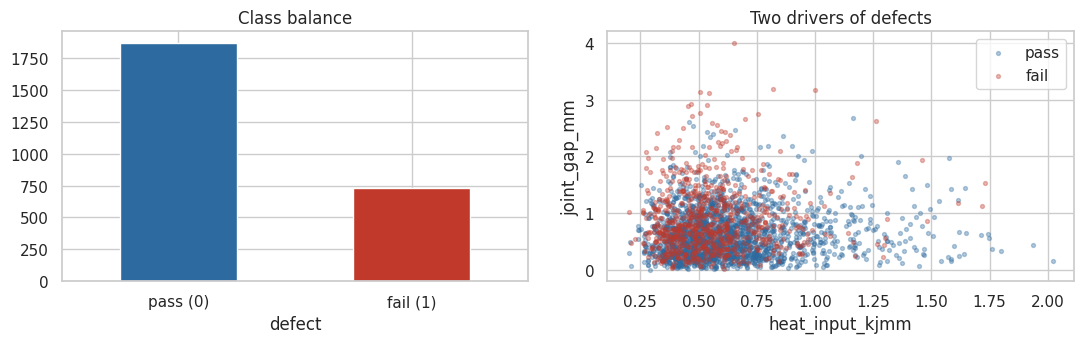

Defects cluster at extreme heat input and large joint gaps — but classes overlap (no perfect line).


In [ ]:
# -----------------------------------------------------------
# 🔹 1A. CLASS BALANCE + A 2-D LOOK AT SEPARABILITY
# -----------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
df.defect.value_counts().plot(kind='bar', color=['#2D6A9F', '#C0392B'], ax=ax[0])
ax[0].set_xticklabels(['pass (0)', 'fail (1)'], rotation=0); ax[0].set_title('Class balance')
for v, c, lab in [(0, '#2D6A9F', 'pass'), (1, '#C0392B', 'fail')]:
    d = df[df.defect == v]
    ax[1].scatter(d.heat_input_kjmm, d.joint_gap_mm, s=8, alpha=0.35, color=c, label=lab)
ax[1].set_xlabel('heat_input_kjmm'); ax[1].set_ylabel('joint_gap_mm')
ax[1].set_title('Two drivers of defects'); ax[1].legend()
plt.tight_layout(); plt.show()
print('Defects cluster at extreme heat input and large joint gaps — but classes overlap (no perfect line).')


In [ ]:

# -----------------------------------------------------------
# 🔹 1B. X / y + TRAIN-TEST SPLIT (stratified)
# -----------------------------------------------------------
from sklearn.model_selection import train_test_split
y = df['defect']
X = df.drop(columns='defect')
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42)
print('train:', X_train.shape, '| test:', X_test.shape)
print('stratify keeps the defect rate equal in train & test:',
      round(y_train.mean(), 3), round(y_test.mean(), 3))

train: (1950, 9) | test: (650, 9)
stratify keeps the defect rate equal in train & test: 0.281 0.282


In [ ]:

# -----------------------------------------------------------
# 🔹 2A. PIPELINE (scale + one-hot) + LOGISTIC REGRESSION
# -----------------------------------------------------------
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
num = X.select_dtypes('number').columns.tolist()
cat = ['material']
pre = ColumnTransformer([('num', StandardScaler(), num),
                         ('cat', OneHotEncoder(drop='first'), cat)])
clf = Pipeline([('prep', pre), ('lr', LogisticRegression(max_iter=2000))]).fit(X_train, y_train)
proba = clf.predict_proba(X_test)[:, 1]      # P(defect)
print('first 5 predicted defect probabilities:', proba[:5].round(3))
print('logistic regression outputs a probability, not just a label.')

first 5 predicted defect probabilities: [0.189 0.429 0.322 0.647 0.181]
logistic regression outputs a probability, not just a label.


In [ ]:

# 1. model accuracy
from sklearn.metrics import accuracy_score
print('accuracy:', round(accuracy_score(y_test, proba > 0.5), 3))
#
# YOUR CODE HERE

# 2. always-pass accuracy
print('always-pass accuracy:', round(y_test.mean(), 3))

#
# YOUR CODE HERE


# 3. why accuracy misleads here: ...   (comment)

In [ ]:
from sklearn.metrics import classification_report

# Make predictions (labels) on the test set using the trained classifier
y_pred = clf.predict(X_test)

# Generate and print the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['pass (0)', 'fail (1)']))

Classification Report:
              precision    recall  f1-score   support

    pass (0)       0.75      0.93      0.83       467
    fail (1)       0.54      0.22      0.31       183

    accuracy                           0.73       650
   macro avg       0.65      0.57      0.57       650
weighted avg       0.69      0.73      0.68       650



### Why a Classification Report is Important for Imbalanced Datasets

In imbalanced datasets, where one class significantly outnumbers the other (as is the case with 'pass' vs. 'fail' welds):

*   **Accuracy** can be misleading. A model that simply predicts the majority class for all instances can achieve high accuracy while performing poorly on the minority class.

*   **Precision** (Positive Predictive Value): The proportion of positive identifications that were actually correct. For the 'fail' class, it tells us how many of the predicted defects were actual defects.

*   **Recall** (Sensitivity or True Positive Rate): The proportion of actual positives that were identified correctly. For the 'fail' class, it tells us how many of the actual defects our model successfully found.

*   **F1-score**: The harmonic mean of precision and recall. It's a useful metric when you want to seek a balance between precision and recall, especially in cases with uneven class distribution.

By examining these metrics for both classes, especially the minority class ('fail' in this case), you get a much clearer picture of your model's performance and its ability to correctly identify the critical instances.

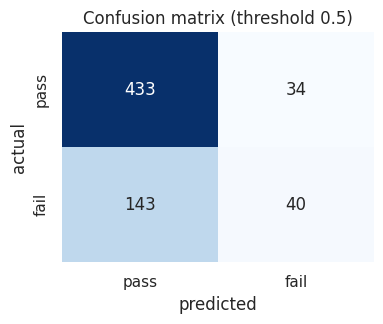

              precision    recall  f1-score   support

           0      0.752     0.927     0.830       467
           1      0.541     0.219     0.311       183

    accuracy                          0.728       650
   macro avg      0.646     0.573     0.571       650
weighted avg      0.692     0.728     0.684       650



In [ ]:
# -----------------------------------------------------------
# 🔹 3A. CONFUSION MATRIX + CLASSIFICATION REPORT
# -----------------------------------------------------------
from sklearn.metrics import confusion_matrix, classification_report
y_pred = clf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(4, 3.4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['pass', 'fail'], yticklabels=['pass', 'fail'], ax=ax)
ax.set_xlabel('predicted'); ax.set_ylabel('actual'); ax.set_title('Confusion matrix (threshold 0.5)')
plt.tight_layout(); plt.show()
print(classification_report(y_test, y_pred, digits=3))

In [ ]:
# 1. read precision/recall for the 'fail' (1) class from the report above

# 2. which matters more for safety, and why? ...   (comment)

In [ ]:
from sklearn.metrics import precision_score, recall_score

# Let's try a lower threshold, e.g., 0.3
new_threshold = 0.3

# Make predictions with the new threshold
y_pred_new_threshold = (proba > new_threshold).astype(int)

# Calculate recall and precision for the 'fail' class (class 1)
recall_fail_new = recall_score(y_test, y_pred_new_threshold, pos_label=1)
precision_fail_new = precision_score(y_test, y_pred_new_threshold, pos_label=1)

print(f"Recall for 'fail' class at threshold {new_threshold}: {recall_fail_new:.3f}")
print(f"Precision for 'fail' class at threshold {new_threshold}: {precision_fail_new:.3f}")
print("Note how recall increased, but precision likely decreased compared to threshold 0.5")

Recall for 'fail' class at threshold 0.3: 0.590
Precision for 'fail' class at threshold 0.3: 0.444
Note how recall increased, but precision likely decreased compared to threshold 0.5


### Precision-Recall Curve

To better understand the trade-off between precision and recall at various thresholds, we can plot a Precision-Recall curve. This curve shows how precision and recall change as the decision threshold varies. For imbalanced datasets, the Precision-Recall curve is often more informative than the ROC curve.

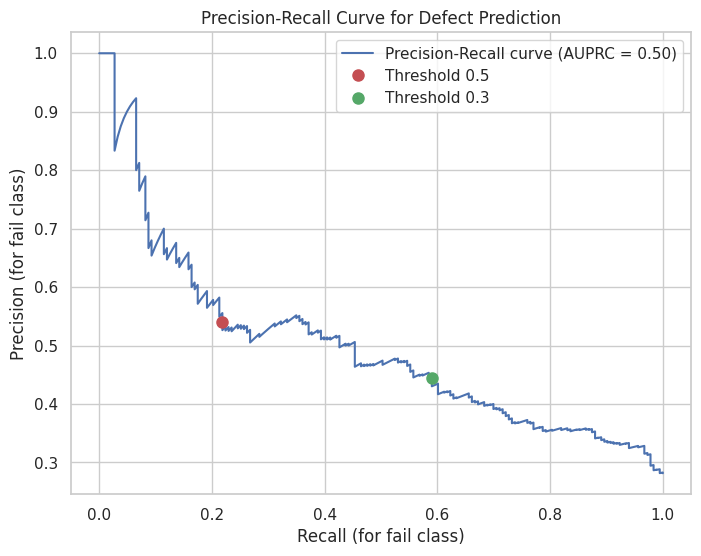

In [ ]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# Calculate precision and recall for various thresholds
precision, recall, thresholds = precision_recall_curve(y_test, proba)

# Calculate Area Under the Precision-Recall Curve (AUPRC)
pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Precision-Recall curve (AUPRC = {pr_auc:.2f})')
plt.xlabel('Recall (for fail class)')
plt.ylabel('Precision (for fail class)')
plt.title('Precision-Recall Curve for Defect Prediction')
plt.grid(True)
plt.legend()

# Mark the current threshold (0.5) if it's in the calculated thresholds
# Find the index of the threshold closest to 0.5
closest_threshold_idx = np.argmin(np.abs(thresholds - 0.5))
plt.plot(recall[closest_threshold_idx], precision[closest_threshold_idx], 'ro', markersize=8, label='Threshold 0.5')

# Optionally, mark the new threshold (0.3) for comparison
closest_new_threshold_idx = np.argmin(np.abs(thresholds - new_threshold))
plt.plot(recall[closest_new_threshold_idx], precision[closest_new_threshold_idx], 'go', markersize=8, label=f'Threshold {new_threshold}')

plt.legend()
plt.show()


From the Precision-Recall curve, you can visually determine a threshold that provides a desirable balance between recall and precision for your specific application's needs. If maximizing recall for 'fail' is paramount (even at the cost of some precision), you would choose a threshold that is further to the right on the curve, which corresponds to a lower probability threshold.

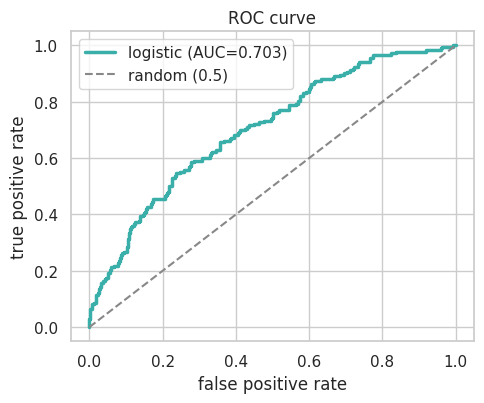

ROC-AUC: 0.703  (1.0 = perfect, 0.5 = random)


In [ ]:
# -----------------------------------------------------------
# 🔹 4A. ROC CURVE ACROSS ALL THRESHOLDS
# -----------------------------------------------------------
from sklearn.metrics import roc_curve, roc_auc_score
fpr, tpr, thr = roc_curve(y_test, proba)
auc = roc_auc_score(y_test, proba)
fig, ax = plt.subplots(figsize=(5, 4.2))
ax.plot(fpr, tpr, color='#3AAFA9', lw=2.5, label=f'logistic (AUC={auc:.3f})')
ax.plot([0, 1], [0, 1], ls='--', color='#888', label='random (0.5)')
ax.set_xlabel('false positive rate'); ax.set_ylabel('true positive rate')
ax.set_title('ROC curve'); ax.legend(); plt.tight_layout(); plt.show()
print(f'ROC-AUC: {auc:.3f}  (1.0 = perfect, 0.5 = random)')

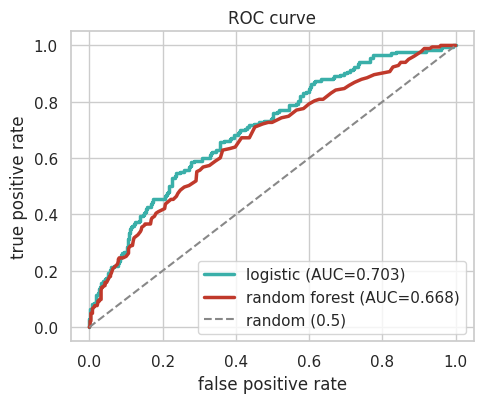

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# 1-2. random forest ROC-AUC + overlay both curves

# Reapply the preprocessing pipeline to X_train and X_test
X_train_processed = pre.fit_transform(X_train)
X_test_processed = pre.transform(X_test)

rf = RandomForestClassifier(n_estimators=200, random_state=42).fit(X_train_processed, y_train)
proba_rf = rf.predict_proba(X_test_processed)[:, 1]
fpr_rf, tpr_rf, thr_rf = roc_curve(y_test, proba_rf)
auc_rf = roc_auc_score(y_test, proba_rf)
fig, ax = plt.subplots(figsize=(5, 4.2))
ax.plot(fpr, tpr, color='#3AAFA9', lw=2.5, label=f'logistic (AUC={auc:.3f})') # Changed tpr0 to tpr
ax.plot(fpr_rf, tpr_rf, color='#C0392B', lw=2.5, label=f'random forest (AUC={auc_rf:.3f})')
ax.plot([0, 1], [0, 1], ls='--', color='#888', label='random (0.5)')
ax.set_xlabel('false positive rate'); ax.set_ylabel('true positive rate')
ax.set_title('ROC curve'); ax.legend(); plt.tight_layout(); plt.show()
#

# 3. which ranks better? ...   (comment)

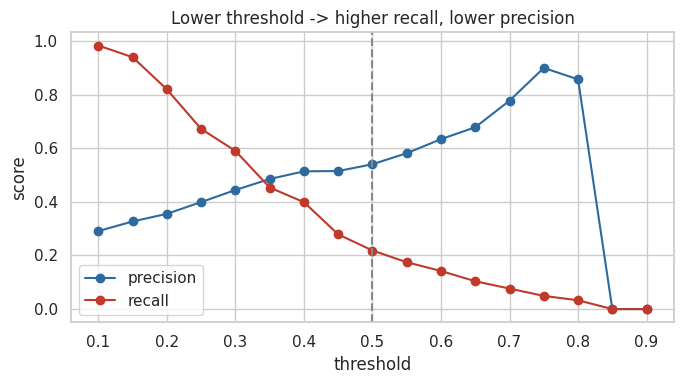

In [ ]:
# -----------------------------------------------------------
# 🔹 5A. PRECISION & RECALL vs THRESHOLD
# -----------------------------------------------------------
from sklearn.metrics import precision_score, recall_score, f1_score
ts = np.linspace(0.1, 0.9, 17)
prec = [precision_score(y_test, (proba >= t).astype(int), zero_division=0) for t in ts]
rec = [recall_score(y_test, (proba >= t).astype(int)) for t in ts]
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ts, prec, 'o-', label='precision', color='#2D6A9F')
ax.plot(ts, rec, 'o-', label='recall', color='#C0392B')
ax.axvline(0.5, ls='--', color='#888'); ax.set_xlabel('threshold'); ax.set_ylabel('score')
ax.set_title('Lower threshold -> higher recall, lower precision'); ax.legend()
plt.tight_layout(); plt.show()

In [ ]:
# 1-2. find threshold for recall >= 0.85, report precision there

# YOUR CODE HERE
min_recall_threshold = 0.85
best_threshold = None
best_precision = 0.0

for i in range(len(ts)):
    if rec[i] >= min_recall_threshold:
        best_threshold = ts[i]
        best_precision = prec[i]
        break

if best_threshold is not None:
    print(f"Threshold for recall >= {min_recall_threshold}: {best_threshold:.3f}")
    print(f"Precision at this threshold: {best_precision:.3f}")
else:
    print(f"No threshold found to achieve recall >= {min_recall_threshold}")

# 3. the trade-off: ...   (comment)

Threshold for recall >= 0.85: 0.100
Precision at this threshold: 0.291


In [ ]:
 # -----------------------------------------------------------
# 🔹 6A. exp(coefficient) = ODDS-RATIO PER +1 SD
# -----------------------------------------------------------
feat_names = clf.named_steps['prep'].get_feature_names_out()
coefs = clf.named_steps['lr'].coef_[0]
odds = pd.Series(np.exp(coefs), index=feat_names).sort_values(ascending=False)
print('Odds-ratio per +1 standardised unit (>1 raises defect odds, <1 lowers):')
print(odds.round(2).to_string())

Odds-ratio per +1 standardised unit (>1 raises defect odds, <1 lowers):
num__joint_gap_mm          1.75
num__plate_thickness_mm    1.25
num__travel_speed_mmps     1.15
num__current_amp           1.06
num__voltage_v             0.96
num__wire_feed_mmps        0.91
num__gas_flow_lpm          0.83
num__heat_input_kjmm       0.80
cat__material_Stainless    0.56
cat__material_Carbon       0.48


In [ ]:
# 1-2. interpret the top/bottom odds-ratios as process advice: ...   (comment)


### Actionable Process Adjustments from Odds Ratios

By interpreting the odds ratios, we can derive insights into which process parameters are most influential in determining the likelihood of a weld defect. An odds ratio greater than 1 means that an increase in the feature's value (by one standard deviation) increases the odds of a defect, while an odds ratio less than 1 means it decreases the odds of a defect.

Here are some key adjustments:

*   **Joint Gap (`num__joint_gap_mm`)**: This feature has the highest odds ratio (1.75). This means that for every one standard deviation increase in `joint_gap_mm`, the odds of a defect increase by 75%. To reduce defects, it is highly advisable to **minimize the joint gap** during welding.

*   **Material (`cat__material_Carbon`, `cat__material_Stainless`)**: Carbon material has the lowest odds ratio (0.48), and Stainless steel (0.56) is also low. This suggests that using Carbon or Stainless steel significantly **reduces the odds of defects** compared to Aluminum (which is the baseline category). If possible, selecting these materials could lead to fewer defects.

*   **Plate Thickness (`num__plate_thickness_mm`)**: With an odds ratio of 1.25, increasing plate thickness increases the odds of a defect. If manufacturing allows, **reducing plate thickness** could help.

*   **Heat Input (`num__heat_input_kjmm`)**: This feature has an odds ratio of 0.80. This indicates that **increasing the heat input** slightly *decreases* the odds of a defect. This might seem counterintuitive if high heat causes problems, but it could mean that within the observed range, slightly more heat helps prevent certain defect types.

*   **Gas Flow (`num__gas_flow_lpm`)**: With an odds ratio of 0.83, **increasing gas flow** helps to *reduce* the odds of a defect. This is critical for preventing porosity.

These insights can guide process engineers in making data-driven decisions to optimize welding parameters and reduce defect rates.